Repartition des etudiants par etablissement
Nombre total d'etudiants: 54

ENI: 16 etudiant(s) (29.6%)
ENS: 13 etudiant(s) (24.1%)
Faculté des sciences : 6 etudiant(s) (11.1%)
faculté des sciences : 3 etudiant(s) (5.6%)
EMIT: 2 etudiant(s) (3.7%)
CNTEMAD: 2 etudiant(s) (3.7%)
faculté : 1 etudiant(s) (1.9%)
CNTEMAD : 1 etudiant(s) (1.9%)
E-Media: 1 etudiant(s) (1.9%)
ENEAM: 1 etudiant(s) (1.9%)
U-Magis: 1 etudiant(s) (1.9%)
Politech-Diego : 1 etudiant(s) (1.9%)
HEI: 1 etudiant(s) (1.9%)
INFOCENTRE: 1 etudiant(s) (1.9%)
IFT: 1 etudiant(s) (1.9%)
Faculté des Sciences : 1 etudiant(s) (1.9%)
OniFRa: 1 etudiant(s) (1.9%)
Faculté des sciences: 1 etudiant(s) (1.9%)


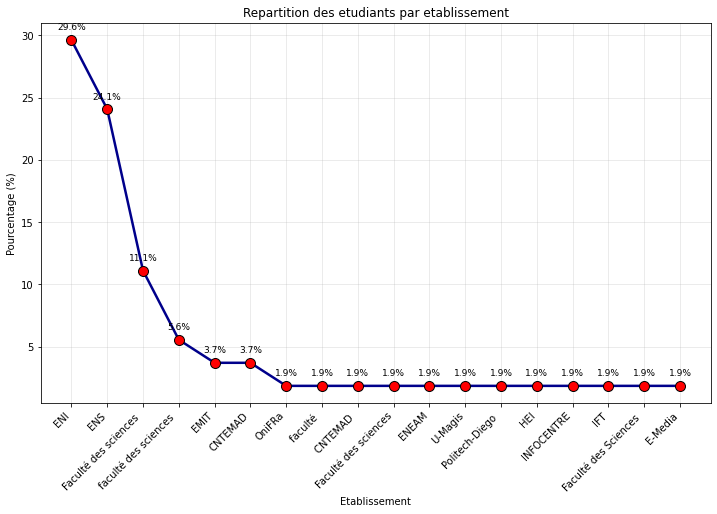


Classement anciens vs novices
Novices (Autres): 38 etudiant(s) (70.4%)
Anciens eleves (ENI): 16 etudiant(s) (29.6%)


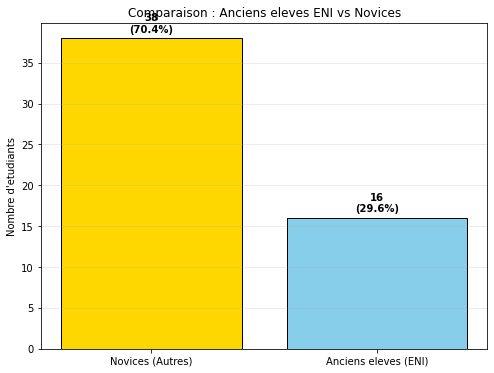

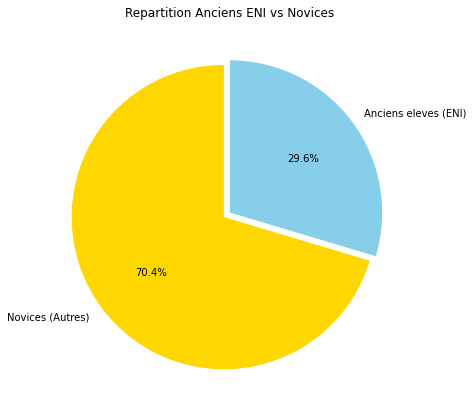

Tous les graphiques ont ete sauvegardes en PNG et PDF


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('m1.csv')

df = df.fillna('')

df = df[~((df['Name'] == '') & (df['Matricule'] == '') & (df['Etablissement d\'origine'] == ''))]

df_students = df[df['Name'] != ''].copy()

etablissement_counts = df_students['Etablissement d\'origine'].value_counts()
total_etudiants = len(df_students)

etablissement_percentages = (etablissement_counts / total_etudiants) * 100

print("Repartition des etudiants par etablissement")
print(f"Nombre total d'etudiants: {total_etudiants}\n")

for etab, count in etablissement_counts.items():
    pct = (count / total_etudiants) * 100
    print(f"{etab}: {count} etudiant(s) ({pct:.1f}%)")

etabs_tries = etablissement_percentages.sort_values(ascending=False)

plt.figure(figsize=(12, 7))
plt.plot(range(len(etabs_tries)), etabs_tries.values, 'o-', 
         linewidth=2.5, markersize=10, color='darkblue',
         markerfacecolor='red', markeredgecolor='black')
plt.xticks(range(len(etabs_tries.index)), etabs_tries.index, rotation=45, ha='right')
plt.ylabel('Pourcentage (%)')
plt.xlabel('Etablissement')
plt.title('Repartition des etudiants par etablissement')
plt.grid(True, alpha=0.3)

for i, (etab, pct) in enumerate(etabs_tries.items()):
    plt.annotate(f'{pct:.1f}%', (i, pct), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontsize=9)

plt.savefig('courbe_pourcentages_etablissements.png', dpi=300, bbox_inches='tight')
plt.savefig('courbe_pourcentages_etablissements.pdf', bbox_inches='tight')
plt.show()

def classer_etablissement(etab):
    if etab == 'ENI':
        return 'Anciens eleves (ENI)'
    else:
        return 'Novices (Autres)'

df_students['Statut'] = df_students['Etablissement d\'origine'].apply(classer_etablissement)

statut_counts = df_students['Statut'].value_counts()
total = len(df_students)

print("\nClassement anciens vs novices")
for statut, count in statut_counts.items():
    pct = (count / total) * 100
    print(f"{statut}: {count} etudiant(s) ({pct:.1f}%)")

plt.figure(figsize=(8, 6))
bars = plt.bar(statut_counts.index, statut_counts.values, 
               color=['gold', 'skyblue'], edgecolor='black')

for bar, count in zip(bars, statut_counts.values):
    pct = (count / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.ylabel("Nombre d'etudiants")
plt.title("Comparaison : Anciens eleves ENI vs Novices")
plt.grid(axis='y', alpha=0.3)

plt.savefig('graphique_anciens_vs_novices.png', dpi=300, bbox_inches='tight')
plt.savefig('graphique_anciens_vs_novices.pdf', bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 7))
plt.pie(statut_counts.values, labels=statut_counts.index, autopct='%1.1f%%',
        colors=['gold', 'skyblue'], startangle=90, explode=(0.05, 0))
plt.title("Repartition Anciens ENI vs Novices")

plt.savefig('camembert_anciens_vs_novices.png', dpi=300, bbox_inches='tight')
plt.savefig('camembert_anciens_vs_novices.pdf', bbox_inches='tight')
plt.show()

print("Tous les graphiques ont ete sauvegardes en PNG et PDF")